In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [18]:
# Generate a synthetic binary classification dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42,
    class_sep=1.5
)

In [19]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X):
        y_proba = self.predict_proba(X)
        return np.where(y_proba >= 0.5, 1, 0)
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):    
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)  
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")
    

In [21]:
model = LogisticRegressionScratch(lr=0.1, epochs=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nFinal Weights:", model.weights)
print("Final Bias:", model.bias)
print("Test Accuracy:", accuracy)

Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.187353
Epoch  200 | Loss: 0.168438
Epoch  300 | Loss: 0.162399
Epoch  400 | Loss: 0.159636
Epoch  500 | Loss: 0.158155
Epoch  600 | Loss: 0.157286
Epoch  700 | Loss: 0.156748
Epoch  800 | Loss: 0.156402
Epoch  900 | Loss: 0.156173

Final Weights: [ 2.92168154 -0.35270156]
Final Bias: -0.473654575280898
Test Accuracy: 1.0


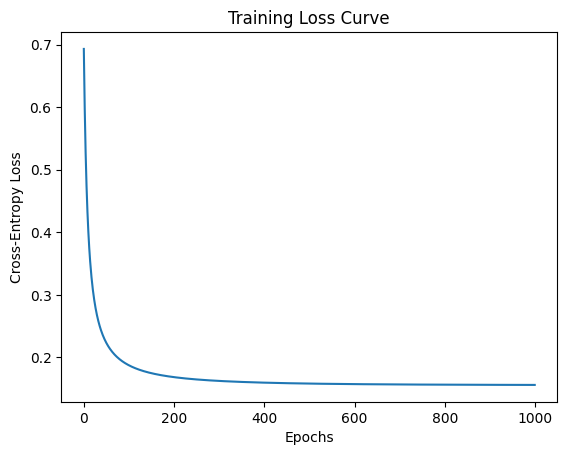

In [22]:
plt.plot(model.loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.show()

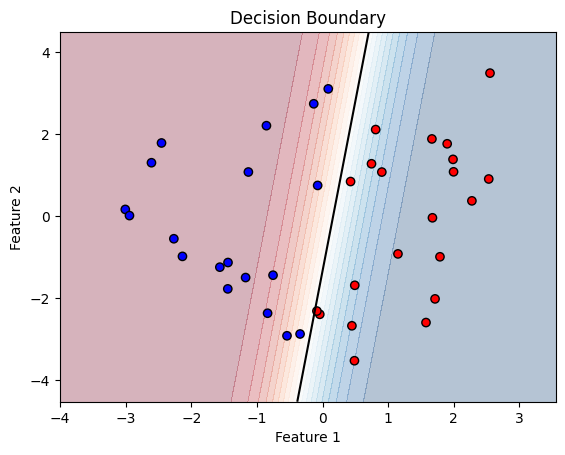

In [23]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.contourf(xx, yy, probs, alpha=0.3, levels=20, cmap="RdBu")
    plt.contour(xx, yy, probs, levels=[0.5], colors='black')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors='k')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X_test, y_test)